<a href="https://colab.research.google.com/github/Adithyasajeev22/EDA/blob/main/HOTEL_BOOKING_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CLASSIFICATION

# 1.LOAD AND DISPLAY THE DATASET

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv("/content/hotel_bookings (1).csv")
df.head(5)
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


# 2.UNDERSTAND THE DATA TYPES AND SUMMARY

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

# 3.DATA CLEANING

In [ ]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [ ]:
df.drop('company',axis=1,inplace=True)

In [ ]:
df.dropna(subset=['children'],inplace=True)

In [ ]:
df['country'].fillna(df['country'].mode()[0],inplace=True)
df['agent'].fillna(df['agent'].mode()[0],inplace=True)

/tmp/ipykernel_4323/3606431437.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['country'].fillna(df['country'].mode()[0],inplace=True)
/tmp/ipykernel_4323/3606431437.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

In [ ]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [ ]:
df.duplicated().sum()

np.int64(32021)

In [ ]:
df.shape

(119386, 31)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.shape

(87365, 31)

# 4.VISUALIZATION

<function matplotlib.pyplot.show(close=None, block=None)>

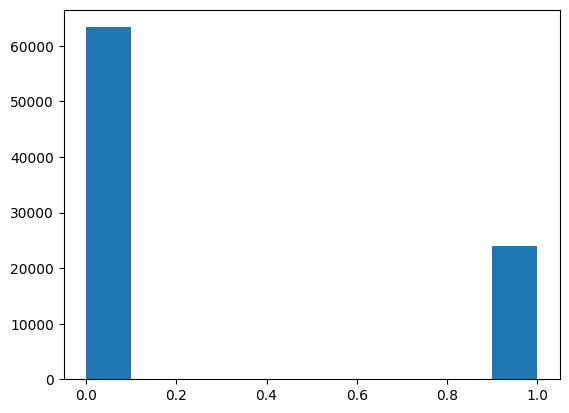

In [ ]:
plt.hist(df['is_canceled'])
plt.show

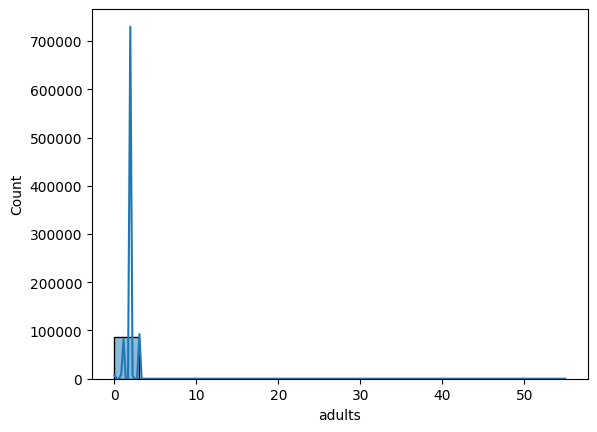

In [ ]:
sns.histplot(df['adults'],kde=True)
plt.show()

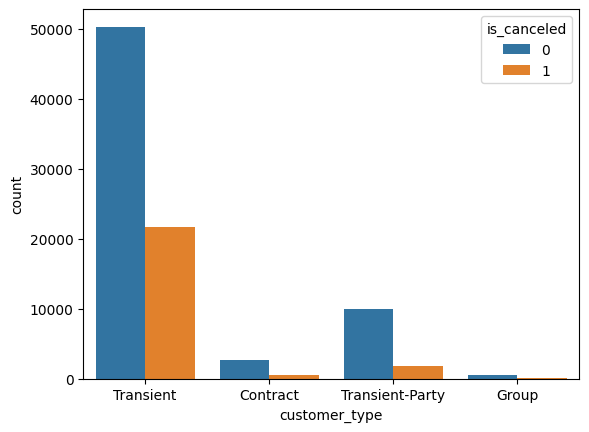

In [ ]:
sns.countplot(data=df,x='customer_type',hue='is_canceled')
plt.show()

# 5.CORRELATION ANALYSIS IN EDA

In [ ]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,3,No Deposit,9.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,4,No Deposit,9.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,No Deposit,9.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,No Deposit,304.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,No Deposit,240.0,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 87365 entries, 0 to 119389
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87365 non-null  object 
 1   is_canceled                     87365 non-null  int64  
 2   lead_time                       87365 non-null  int64  
 3   arrival_date_year               87365 non-null  int64  
 4   arrival_date_month              87365 non-null  object 
 5   arrival_date_week_number        87365 non-null  int64  
 6   arrival_date_day_of_month       87365 non-null  int64  
 7   stays_in_weekend_nights         87365 non-null  int64  
 8   stays_in_week_nights            87365 non-null  int64  
 9   adults                          87365 non-null  int64  
 10  children                        87365 non-null  float64
 11  babies                          87365 non-null  int64  
 12  meal                            8736

In [ ]:
print(df['hotel'].unique()) #nominal

['Resort Hotel' 'City Hotel']


In [ ]:
print(df['arrival_date_month'].unique()) #ordinal

['July' 'August' 'September' 'October' 'November' 'December' 'January'
 'February' 'March' 'April' 'May' 'June']


In [ ]:
print(df['deposit_type'].unique())  #nominal

['No Deposit' 'Refundable' 'Non Refund']


In [ ]:
print(df['customer_type'].unique()) #nominal

['Transient' 'Contract' 'Transient-Party' 'Group']


In [ ]:
print(df['reservation_status'].unique()) #nominal

['Check-Out' 'Canceled' 'No-Show']


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

df['hotel']=le.fit_transform(df['hotel'])
df['deposit_type']=le.fit_transform(df['deposit_type'])
df['customer_type']=le.fit_transform(df['customer_type'])
df['reservation_status']=le.fit_transform(df['reservation_status'])

In [ ]:
df["arrival_date_month"].replace(['July','August','September','October','November','December','January','February','March','April','May','June'],[0,1,2,3,4,5,6,7,8,9,10,11],inplace=True)

/tmp/ipykernel_4323/1531855441.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["arrival_date_month"].replace(['July','August','September','October','November','December','January','February','March','April','May','June'],[0,1,2,3,4,5,6,7,8,9,10,11],inplace=True)
/tmp/ipykernel_4323/1531855441.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd

In [ ]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,1,0,342,2015,0,27,1,0,0,2,...,3,0,9.0,0,2,0.0,0,0,1,2015-07-01
1,1,0,737,2015,0,27,1,0,0,2,...,4,0,9.0,0,2,0.0,0,0,1,2015-07-01
2,1,0,7,2015,0,27,1,0,1,1,...,0,0,9.0,0,2,75.0,0,0,1,2015-07-02
3,1,0,13,2015,0,27,1,0,1,1,...,0,0,304.0,0,2,75.0,0,0,1,2015-07-02
4,1,0,14,2015,0,27,1,0,2,2,...,0,0,240.0,0,2,98.0,0,1,1,2015-07-03


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 87365 entries, 0 to 119389
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87365 non-null  int64  
 1   is_canceled                     87365 non-null  int64  
 2   lead_time                       87365 non-null  int64  
 3   arrival_date_year               87365 non-null  int64  
 4   arrival_date_month              87365 non-null  int64  
 5   arrival_date_week_number        87365 non-null  int64  
 6   arrival_date_day_of_month       87365 non-null  int64  
 7   stays_in_weekend_nights         87365 non-null  int64  
 8   stays_in_week_nights            87365 non-null  int64  
 9   adults                          87365 non-null  int64  
 10  children                        87365 non-null  float64
 11  babies                          87365 non-null  int64  
 12  meal                            8736

In [ ]:
print(df['meal'].unique())

['BB' 'FB' 'HB' 'SC' 'Undefined']


In [ ]:
print(df['country'].unique())

['PRT' 'GBR' 'USA' 'ESP' 'IRL' 'FRA' 'ROU' 'NOR' 'OMN' 'ARG' 'POL' 'DEU'
 'BEL' 'CHE' 'CN' 'GRC' 'ITA' 'NLD' 'DNK' 'RUS' 'SWE' 'AUS' 'EST' 'CZE'
 'BRA' 'FIN' 'MOZ' 'BWA' 'LUX' 'SVN' 'ALB' 'IND' 'CHN' 'MEX' 'MAR' 'UKR'
 'SMR' 'LVA' 'PRI' 'SRB' 'CHL' 'AUT' 'BLR' 'LTU' 'TUR' 'ZAF' 'AGO' 'ISR'
 'CYM' 'ZMB' 'CPV' 'ZWE' 'DZA' 'KOR' 'CRI' 'HUN' 'ARE' 'TUN' 'JAM' 'HRV'
 'HKG' 'IRN' 'GEO' 'AND' 'GIB' 'URY' 'JEY' 'CAF' 'CYP' 'COL' 'GGY' 'KWT'
 'NGA' 'MDV' 'VEN' 'SVK' 'FJI' 'KAZ' 'PAK' 'IDN' 'LBN' 'PHL' 'SEN' 'SYC'
 'AZE' 'BHR' 'NZL' 'THA' 'DOM' 'MKD' 'MYS' 'ARM' 'JPN' 'LKA' 'CUB' 'CMR'
 'BIH' 'MUS' 'COM' 'SUR' 'UGA' 'BGR' 'CIV' 'JOR' 'SYR' 'SGP' 'BDI' 'SAU'
 'VNM' 'PLW' 'QAT' 'EGY' 'PER' 'MLT' 'MWI' 'ECU' 'MDG' 'ISL' 'UZB' 'NPL'
 'BHS' 'MAC' 'TGO' 'TWN' 'DJI' 'STP' 'KNA' 'ETH' 'IRQ' 'HND' 'RWA' 'KHM'
 'MCO' 'BGD' 'IMN' 'TJK' 'NIC' 'BEN' 'VGB' 'TZA' 'GAB' 'GHA' 'TMP' 'GLP'
 'KEN' 'LIE' 'GNB' 'MNE' 'UMI' 'MYT' 'FRO' 'MMR' 'PAN' 'BFA' 'LBY' 'MLI'
 'NAM' 'BOL' 'PRY' 'BRB' 'ABW' 'AIA' 'SLV' 'DMA' 'PY

In [ ]:
print(df['market_segment'].unique())  #nomi

['Direct' 'Corporate' 'Online TA' 'Offline TA/TO' 'Complementary' 'Groups'
 'Aviation']


In [ ]:
print(df['distribution_channel'].unique()) #nomi

['Direct' 'Corporate' 'TA/TO' 'Undefined' 'GDS']


In [ ]:
print(df['reserved_room_type'].unique()) #nomi

['C' 'A' 'D' 'E' 'G' 'F' 'H' 'L' 'P' 'B']


In [ ]:
print(df['assigned_room_type'].unique()) #nomi

['C' 'A' 'D' 'E' 'G' 'F' 'I' 'B' 'H' 'P' 'L' 'K']


In [ ]:
print(df['reservation_status_date'].unique())

['2015-07-01' '2015-07-02' '2015-07-03' '2015-05-06' '2015-04-22'
 '2015-06-23' '2015-07-05' '2015-07-06' '2015-07-07' '2015-07-08'
 '2015-05-11' '2015-07-15' '2015-07-16' '2015-05-29' '2015-05-19'
 '2015-06-19' '2015-05-23' '2015-05-18' '2015-07-09' '2015-06-02'
 '2015-07-13' '2015-07-04' '2015-06-29' '2015-06-16' '2015-06-18'
 '2015-06-12' '2015-06-09' '2015-05-26' '2015-07-11' '2015-07-12'
 '2015-07-17' '2015-04-15' '2015-05-13' '2015-07-10' '2015-05-20'
 '2015-05-12' '2015-07-14' '2015-06-17' '2015-05-01' '2015-03-30'
 '2015-07-19' '2015-06-03' '2015-06-26' '2015-05-14' '2015-07-20'
 '2015-05-07' '2015-05-28' '2015-04-13' '2015-03-25' '2015-07-21'
 '2015-06-27' '2015-07-18' '2015-07-23' '2015-06-08' '2015-06-22'
 '2015-06-24' '2015-03-05' '2015-06-01' '2015-04-24' '2015-07-22'
 '2015-05-27' '2015-04-06' '2015-04-11' '2015-07-25' '2015-07-28'
 '2015-07-29' '2015-06-25' '2015-07-24' '2015-06-05' '2015-06-30'
 '2015-06-13' '2015-06-11' '2015-07-30' '2015-07-27' '2015-04-29'
 '2015-06-

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

df['meal']=le.fit_transform(df['meal'])
df['country']=le.fit_transform(df['country'])
df['market_segment']=le.fit_transform(df['market_segment'])
df['distribution_channel']=le.fit_transform(df['distribution_channel'])
df['reserved_room_type']=le.fit_transform(df['reserved_room_type'])
df['assigned_room_type']=le.fit_transform(df['assigned_room_type'])



In [ ]:
from pandas import core
df['reservation_status_date']=pd.to_numeric(df['reservation_status_date'],errors='coerce')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 87365 entries, 0 to 119389
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87365 non-null  int64  
 1   is_canceled                     87365 non-null  int64  
 2   lead_time                       87365 non-null  int64  
 3   arrival_date_year               87365 non-null  int64  
 4   arrival_date_month              87365 non-null  int64  
 5   arrival_date_week_number        87365 non-null  int64  
 6   arrival_date_day_of_month       87365 non-null  int64  
 7   stays_in_weekend_nights         87365 non-null  int64  
 8   stays_in_week_nights            87365 non-null  int64  
 9   adults                          87365 non-null  int64  
 10  children                        87365 non-null  float64
 11  babies                          87365 non-null  int64  
 12  meal                            8736

In [ ]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [ ]:
df.drop(['reservation_status_date'],axis=1,inplace=True)

In [ ]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


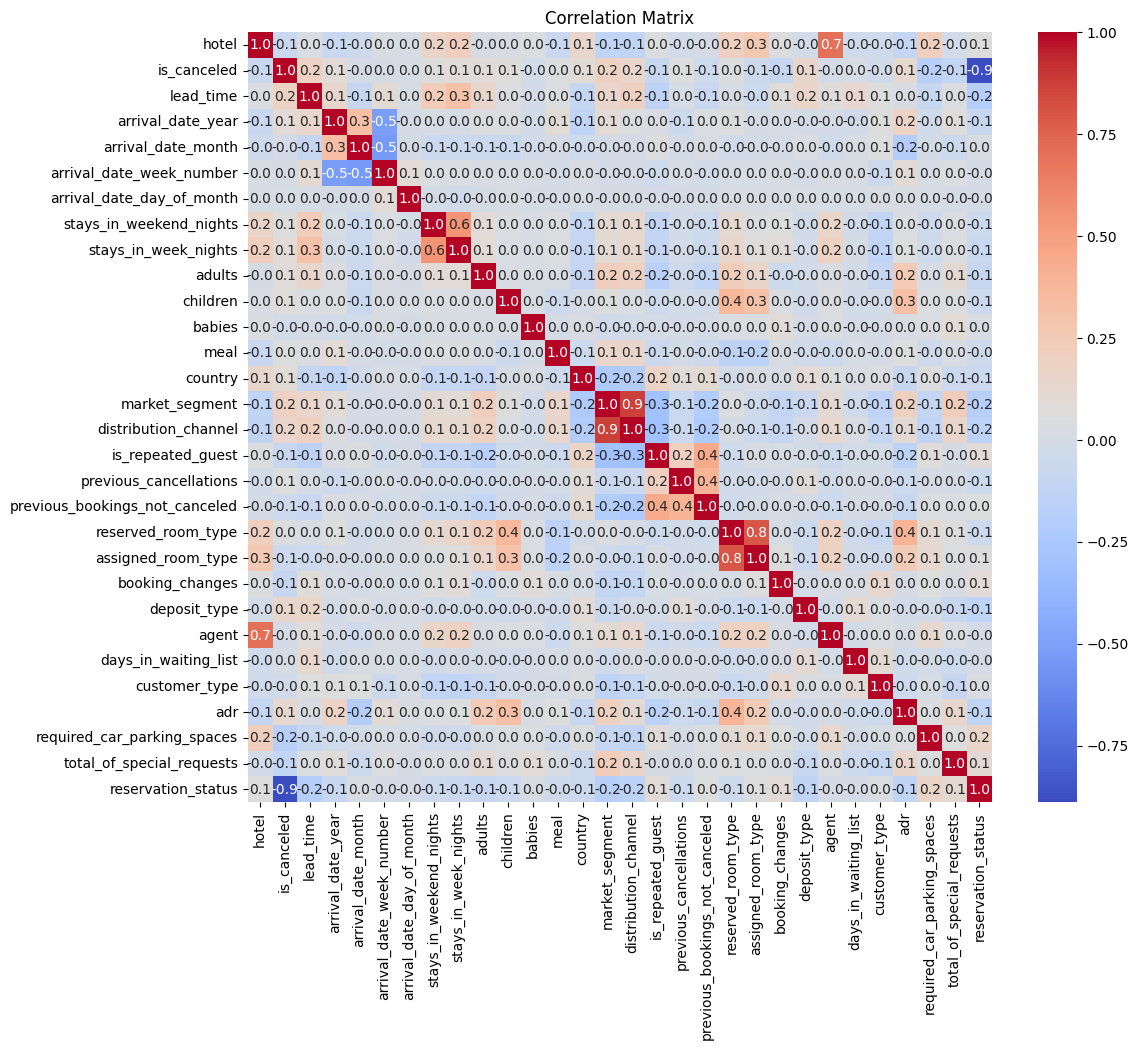

In [ ]:
# Correlation matrix
corr_matrix=df.corr()
plt.figure(figsize=(12,10))

# Heatmap of correlation matrix
sns.heatmap(corr_matrix,annot=True,fmt='0.01f',cmap='coolwarm') # 0.01f should be given for float values, d for integers
plt.title('Correlation Matrix')
plt.show()

In [ ]:
df.drop(['reserved_room_type','assigned_room_type','market_segment','distribution_channel'],axis=1,inplace=True)

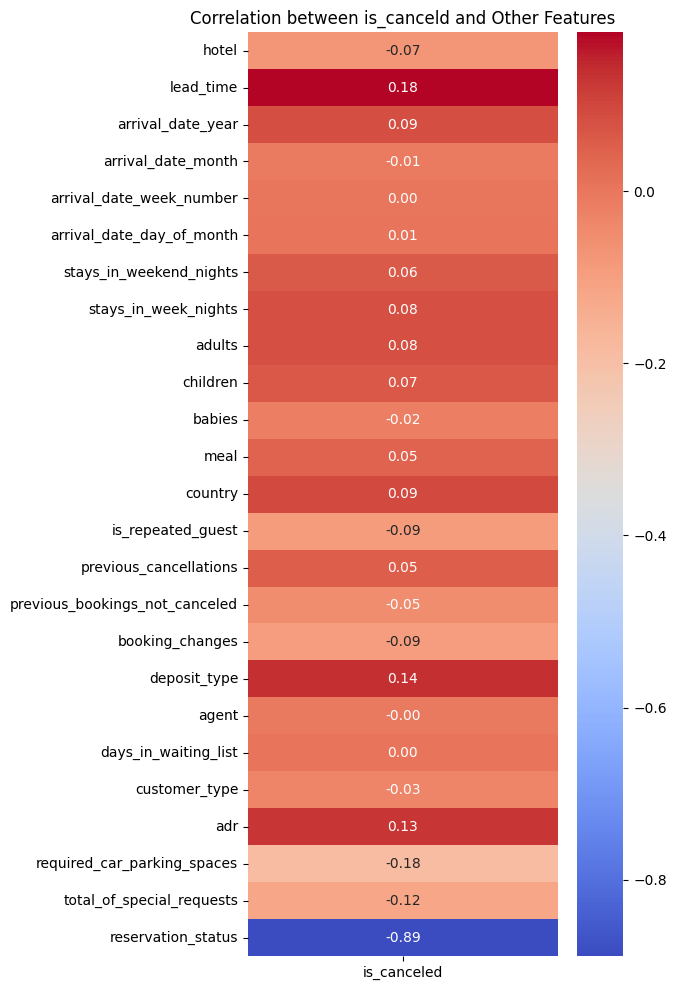

In [ ]:
canceled_corr=df.corr()['is_canceled']
canceled_corr=canceled_corr.drop('is_canceled')

plt.figure(figsize=(5,12))
sns.heatmap(canceled_corr.to_frame(),annot=True,fmt='.2f',cmap='coolwarm',cbar=True,annot_kws={'size':10})
plt.title('Correlation between is_canceld and Other Features')
plt.show()

In [ ]:
df.drop(['customer_type','days_in_waiting_list','agent','babies','arrival_date_day_of_month','arrival_date_week_number','arrival_date_month'],axis=1,inplace=True)

In [ ]:
df.shape

(87365, 19)

# 6.OUTLIER CHECKING AND REMOVING

<Axes: >

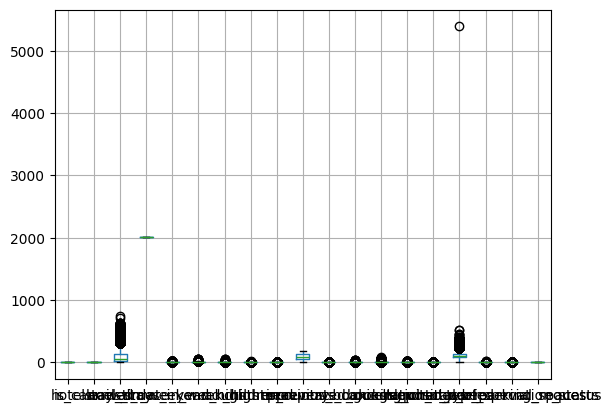

In [ ]:
df.boxplot()

In [ ]:
df.shape

(87365, 19)

In [ ]:
def remove_outlier_iqr(df,exclude_column):
  for col in df.columns:
    if col==exclude_column:
      continue
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    iqr=q3-q1
    lower_bound=q1-1.5*iqr
    upper_bound=q3+1.5*iqr

    df=df[(df[col]>=lower_bound) & (df[col]<=upper_bound)]
  return df

df_cleaned=remove_outlier_iqr(df,exclude_column='is_canceled')
df=df_cleaned

In [ ]:
df.shape

(31910, 19)

# 7.DATA SCALING

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

features=['hotel','is_canceled','lead_time','arrival_date_year','stays_in_weekend_nights','stays_in_week_nights','adults','children','is_repeated_guest','previous_cancellations',	'previous_bookings_not_canceled','booking_changes','deposit_type','adr','required_car_parking_spaces','total_of_special_requests','reservation_status']
scaler=MinMaxScaler()
scaled_data=scaler.fit_transform(df[features])
scaled_df=pd.DataFrame(scaled_data,columns=features)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd

x=df[['hotel','lead_time','arrival_date_year','stays_in_weekend_nights','stays_in_week_nights','adults','children','is_repeated_guest','previous_cancellations',	'previous_bookings_not_canceled','booking_changes','deposit_type','adr','required_car_parking_spaces','total_of_special_requests','reservation_status']]
y=df['is_canceled']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

model=LogisticRegression()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print(f'Baseline model accuracy:{accuracy:.2f}')

Baseline model accuracy:0.99


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
